In [1]:
from phipml.io.data_handler import Config, MetadataHandler, OligosHandler, FeatureManager
from phipml.plots.metrics_helpers import *
from phipml.plots.helpers import  (
    generate_feature_importance_table, plot_shap_values, plot_table_top_features,
    barplot_counts_fisher_test, boxplot_compare_distribution_by_category)

import gc
from matplotlib.colors import LinearSegmentedColormap
import os
import joblib
from tabulate import tabulate


#ML
from sklearn import set_config
set_config(transform_output = "pandas")
from concurrent.futures import ThreadPoolExecutor, as_completed
import glob

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [27]:
config_file = "../Metadata/config_standard.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
#oligos_handler = OligosHandler(config)
oligos_handler = OligosHandler(config) #, data_type=config.data_types[0])
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                 subgroup = 'all',
                                 with_oligos=True,
                                 with_additional_features = False,
                                 filter_by_entropy=False,
                                 prevalence_threshold_min=0,
                                 prevalence_threshold_max=100)
X_train, y_train = feature_manager.get_features_target()
X_train.shape

(180, 65383)

In [19]:
base_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Data/Classification/Diagnostics/Controls_HCC/"
figures_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/ML"
pattern  = os.path.join(base_dir, '*', 'nested_predictions_HCC_*.joblib')
files    = glob.glob(pattern)

In [28]:
d = joblib.load("/home/creyna/Vogl-lab_Projects_git/HCC/Data/Classification/Diagnostics/Controls_HCC/all/nested_predictions_HCC_1.joblib")['train_shap_values']
if 'twist_47590' in d.columns:
    d = d.drop('twist_47590', axis=1)
X_train = X_train.loc[d.index, d.columns]
y_train = y_train.loc[d.index]
shap_values =  pd.DataFrame(0.0, index=d.index, columns=d.columns)
for fn in files:
    df = joblib.load(fn)['train_shap_values']  # DataFrame n_samples×n_features
    shap_values += df
    del df
shap_values /= len(files)
number_peptides = len(shap_values.columns)

,agilent_10,agilent_100036,agilent_100163,agilent_100179,agilent_100240,agilent_100245,agilent_10026,agilent_100272,agilent_100362,agilent_100413,...,twist_99262,twist_99298,twist_99409,twist_99522,twist_99523,twist_99692,twist_99693,twist_99753,twist_99804,twist_99873
SampleName,,,,,,,,,,,,,,,,,,,,,
R14P01_79_0106492769_HCC_MUW_A_T_C2,0.0,0.0,0.0,0.000000,0.001297,-0.000092,0.0,0.000000,0.000000,-0.000010,...,0.000123,0.000000,0.0,0.0,0.0,0.0,-0.000252,0.0,0.0,0.000000
R14P01_80_0105421207_HCC_MUW_A_T_C2,0.0,0.0,0.0,0.000000,0.002814,-0.000244,0.0,0.000000,0.000011,-0.000023,...,0.000064,0.000000,0.0,0.0,0.0,0.0,-0.000265,0.0,0.0,0.000000
R14P02_01_1051918927_HCC_MUW_A_T_C2,0.0,0.0,0.0,0.000171,0.001170,-0.000080,0.0,-0.000001,0.000000,-0.000065,...,0.000012,0.000000,0.0,0.0,0.0,0.0,-0.000454,0.0,0.0,0.000007
R14P02_02_1052026872_HCC_MUW_A_T_C2,0.0,0.0,0.0,0.000000,-0.001111,-0.000119,0.0,0.000000,0.000000,-0.000026,...,0.000102,0.000000,0.0,0.0,0.0,0.0,0.003147,0.0,0.0,0.000005
R14P02_03_1105220536_HCC_MUW_A_T_C2,0.0,0.0,0.0,0.000000,0.000507,-0.000144,0.0,0.000000,0.000000,-0.000020,...,0.000120,0.000000,0.0,0.0,0.0,0.0,-0.001167,0.0,0.0,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R22P04_66_HCC594_HCC_MUW_A_T_C2,0.0,0.0,0.0,0.000000,0.000971,-0.000029,0.0,0.000000,0.000011,-0.000150,...,0.000070,0.000000,0.0,0.0,0.0,0.0,0.000135,0.0,0.0,0.000000
R22P04_67_HCC597_HCC_MUW_A_T_C2,0.0,0.0,0.0,0.000000,0.000354,-0.000002,0.0,0.000000,0.000010,-0.000021,...,0.000013,0.000000,0.0,0.0,0.0,0.0,-0.000324,0.0,0.0,0.000000
R22P04_68_HCC666_HCC_MUW_A_T_C2,0.0,0.0,0.0,-0.000043,0.001039,-0.000065,0.0,0.000013,0.000009,-0.000022,...,0.000028,0.000012,0.0,0.0,0.0,0.0,-0.000484,0.0,0.0,0.000103


In [8]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Step 2: Convert to long-form DataFrame
shap_long_df = pd.DataFrame({
    "Feature": mean_abs_shap.index,
    "MeanAbsSHAP": mean_abs_shap.values
})

# Step 3: Sort and optionally filter top N
top_n = 50
top_shap_df = shap_long_df.sort_values(by="MeanAbsSHAP", ascending=False).head(top_n)
top_shap_df

,Feature,MeanAbsSHAP
2343,agilent_200650,0.632639
6237,twist_58680,0.202226
4596,agilent_6423,0.130750
3974,agilent_36653,0.097289
938,agilent_139400,0.094761
4238,agilent_4777,0.086187
3074,agilent_227745,0.083199
1708,agilent_174704,0.077711
2495,agilent_206025,0.074186
4256,agilent_4836,0.066864


In [ ]:
oligos_metadata = oligos_handler.get_oligos_metadata_df()
oligos_metadata.set_index(oligos_metadata.columns[0], inplace=True)
oligos_metadata = oligos_metadata[['Description', 'species', 'genus', 'family','order']]
feature_importance_train = generate_feature_importance_table(shap_values.values, X_train, y_train, oligos_metadata,
                                                             group_tests = config.group_tests, suffix_file=f'nested_CV_{number_peptides}', figures_dir = figures_dir)

In [ ]:
### Manually clean the file in bash for top30
feature_importance_train = pd.read_csv(f'{figures_dir}/shap_values_nested_CV_6694_Controls-HCC_with_oligos_top30.csv')
feature_importance_train["Description"] = feature_importance_train.apply(
    lambda r: f"{r['Organism']}; {r['Description']}" if pd.notna(r["Organism"]) and r["Organism"] != ""
              else r["Description"],
    axis=1
)
feature_importance_train.drop(columns=["Organism"], inplace=True)   # optional
feature_importance_train.to_csv(f'{figures_dir}/shap_values_nested_CV_6694_Controls-HCC_with_oligos_top30_clean.csv', index=True)

In [5]:
#figures_dir = "'/home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/ML/random-forest"
figures_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/ML"
save_dir = "/home/creyna/Vogl-lab_Projects_git/HCC/Reports/plots/Figure4/"

# Control - HCC

<Axes: >

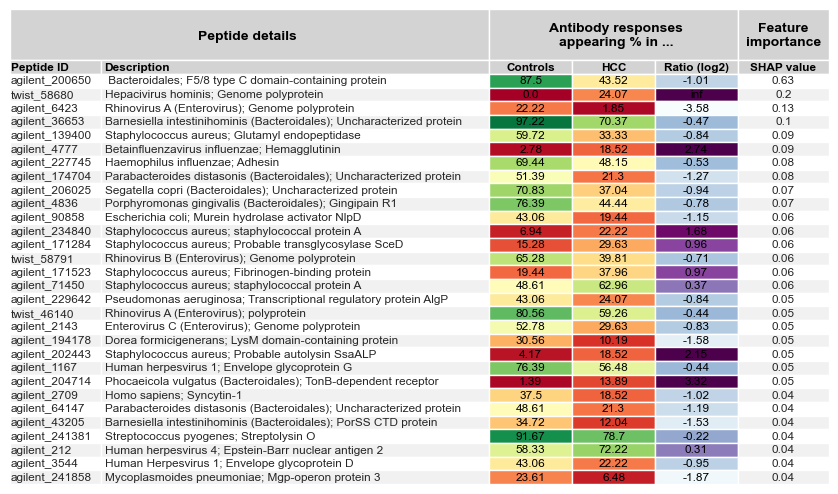

In [8]:
group_tests = ['Controls', 'HCC']
feature_importance_train = pd.read_csv(f'{figures_dir}/xgboost/Tables/Table_shap_Controls-HCC_nested-HCC_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = figures_dir, filename_label=f"{'-'.join(group_tests)}_nested-HCC", save_fig = False)

<Axes: >

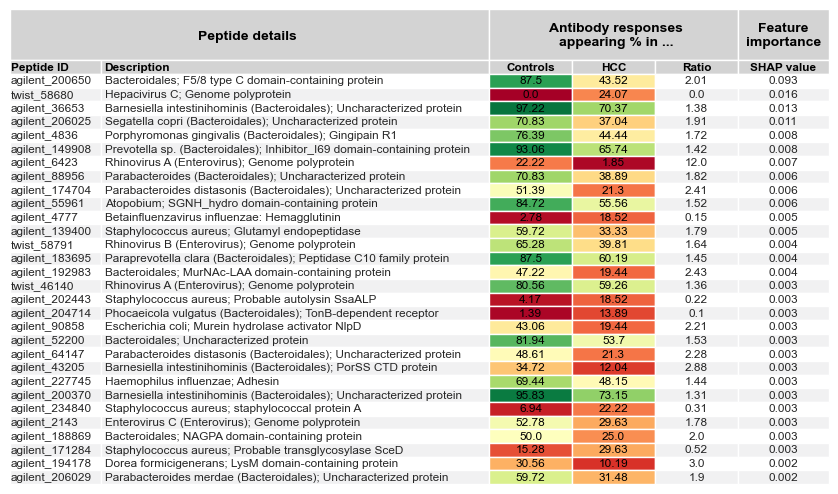

In [8]:
group_tests = ['Controls', 'HCC']
feature_importance_train = pd.read_csv(f'{figures_dir}/random-forest/Tables/Table_shap_Controls-HCC_nested-HCC_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = f"{save_dir}", filename_label =f"{'-'.join(group_tests)}_nested-HCC", save_fig = True)

# Controls - Cirrhosis

<Axes: >

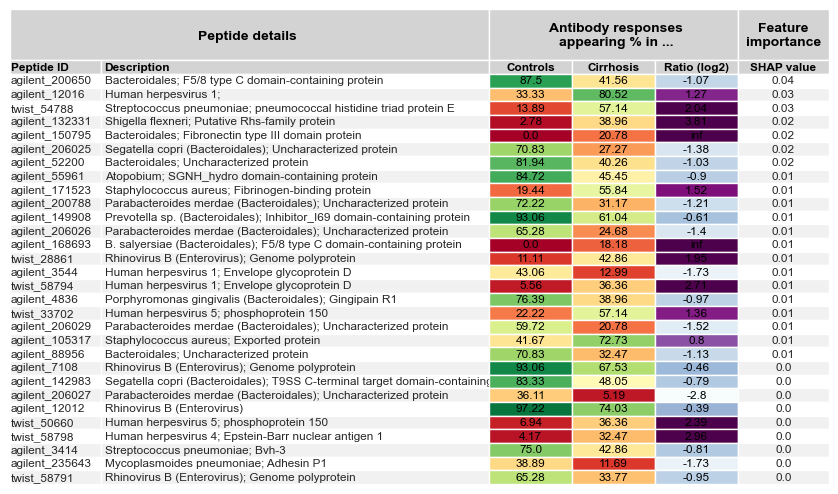

In [26]:
group_tests = ['Controls', 'Cirrhosis']
feature_importance_train = pd.read_csv(f'{figures_dir}/Tables/Table_shap_Controls-Cirrhosis_nested-Cirrhosis_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = figures_dir, filename_label =f"{'-'.join(group_tests)}_nested-Cirrhosis", save_fig = True)

<Axes: >

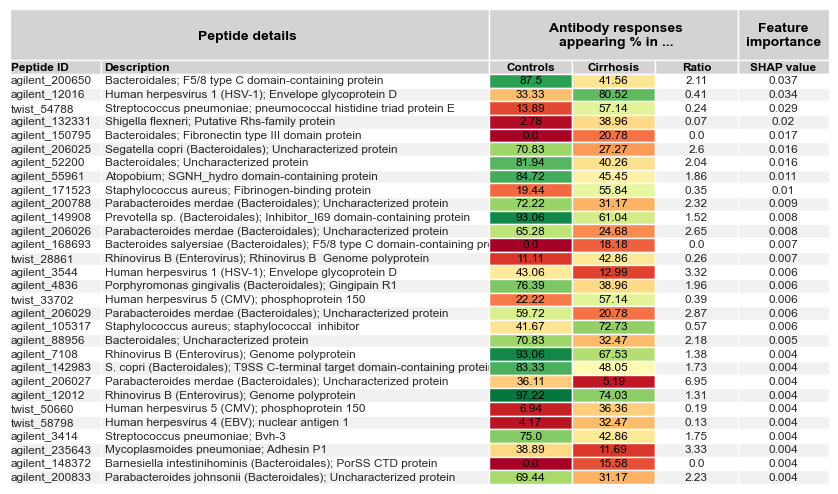

In [10]:
group_tests = ['Controls', 'Cirrhosis']
feature_importance_train = pd.read_csv(f'{figures_dir}/random-forest/Tables/Table_shap_Controls-Cirrhosis_nested-Cirrhosis_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = f"{save_dir}", filename_label =f"{'-'.join(group_tests)}_nested-Cirrhosis", save_fig = True)

# Cirrhosis - HCC

In [ ]:
group_tests = ['Cirrhosis', 'HCC']
feature_importance_train = pd.read_csv(f'{figures_dir}/Tables/Table_shap_Cirrhosis-HCC_nested-HCC_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = figures_dir, filename_label =f"{'-'.join(group_tests)}_nested-HCC", save_fig = False)

<Axes: >

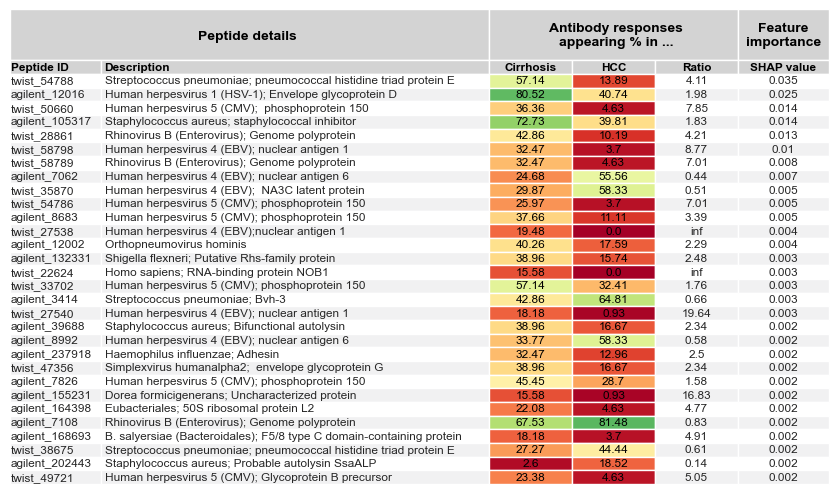

In [43]:
group_tests = ['Cirrhosis', 'HCC']
feature_importance_train = pd.read_csv(f'{figures_dir}/random-forest/Tables/Table_shap_Cirrhosis-HCC_nested-HCC_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = f"{save_dir}", filename_label =f"{'-'.join(group_tests)}_nested-HCC", save_fig = True)

# Controls - Diseases

<Axes: >

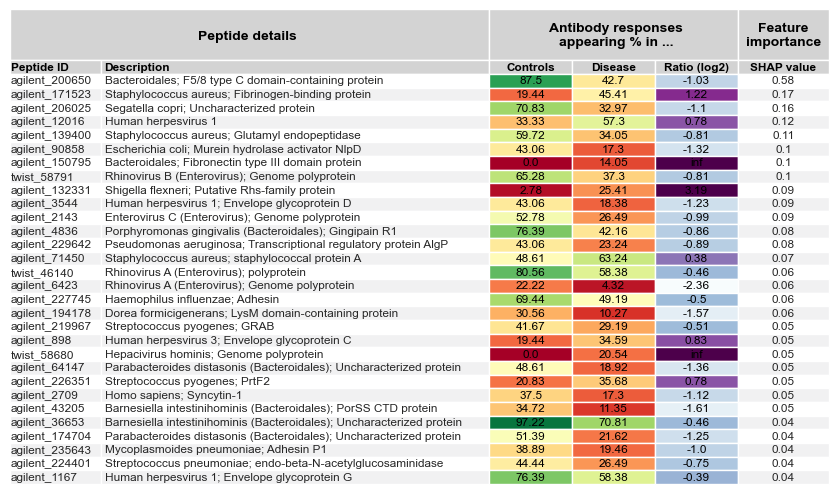

In [21]:
group_tests = ['Controls', 'Disease']
feature_importance_train = pd.read_csv(f'{figures_dir}/Tables/Table_shap_Controls-Disease_nested-HCC_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = figures_dir, filename_label =f"{'-'.join(group_tests)}_nested-HCC", save_fig = True)

<Axes: >

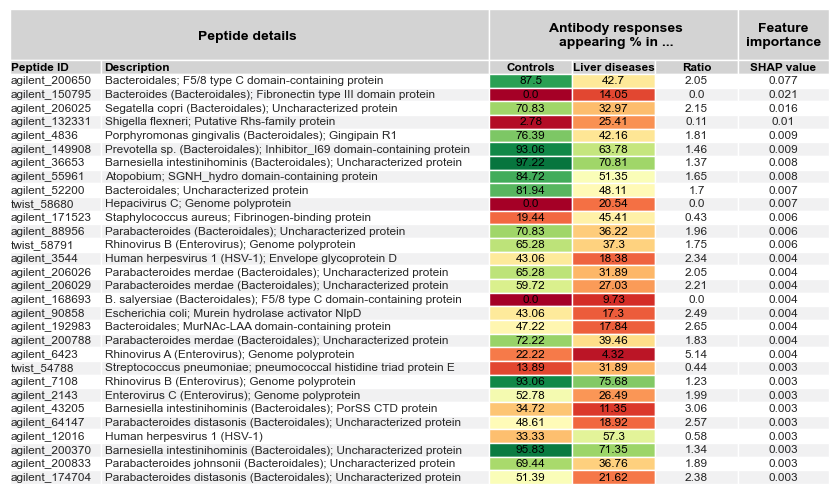

In [12]:
group_tests = ['Controls', 'Liver diseases']
feature_importance_train = pd.read_csv(f'{figures_dir}/random-forest/Tables/Table_shap_Controls-Disease_nested-HCC_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = f"{save_dir}", filename_label =f"{'-'.join(group_tests)}_nested-HCC", save_fig = True)

<Axes: >

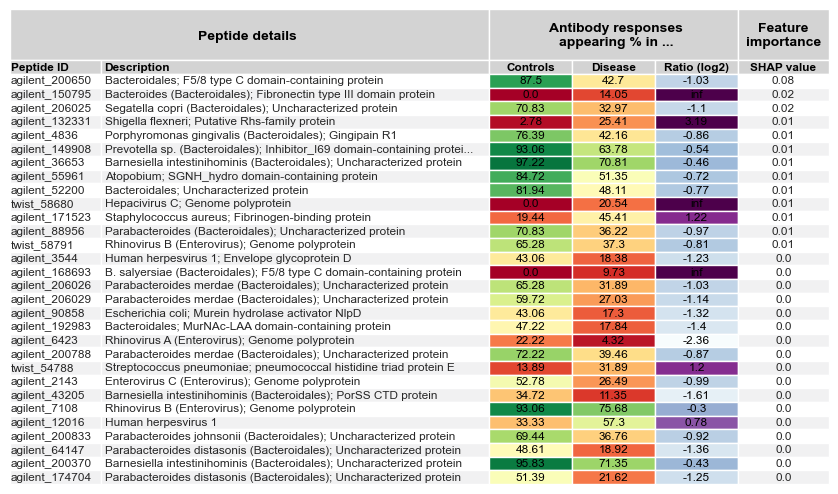

In [4]:
group_tests = ['Controls', 'Disease']
feature_importance_train = pd.read_csv(f'{figures_dir}/random-forest/Tables/Table_shap_Controls-Disease_nested-HCC_withSexAge_with_oligos_top30.csv')
#and make the font size bigger for the content of Peptide ID, Description, Contrls, HCC, Ratio and SHAP value columns,
plot_table_top_features(feature_importance_train,
                        to_select_features = 30,
                        group_tests = group_tests,
                        figure_dir = f"{figures_dir}/random-forest/", filename_label =f"{'-'.join(group_tests)}_nested-HCC_withSexAge", save_fig = True)